In [1]:
import asyncio
from collections import defaultdict
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


In [2]:
import sys
from pathlib import Path

# Asumiendo que notebooks/ está dentro de la raíz del proyecto
root_path = Path().resolve().parent  # sube un nivel
sys.path.append(str(root_path))

In [3]:
from agents.classifier_agent import ClassifierAgent
from agents.aggregator_agent import AggregatorAgent
from data.dataset_registry import DatasetRegistry
from data.loaders.sklearn_loader import SklearnLoader
import pandas as pd


==================== TEST MULTI-AGENT (WINE + SHAP + LIME) ====================
[Dataset] wine cargado → X=(178, 13), y=(178,)
[Dataset] Features: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

[Setup] Inicializando agentes...

[rf_adaptive] Setup iniciado
[rf_adaptive] 19:21:06 | Setup iniciado (train + eval inicial)
[rf_adaptive] 19:21:06 | Entrenando modelo (iter=0)
[rf_adaptive] 19:21:06 | Evaluación completada | acc=0.972
[rf_adaptive] 19:21:06 | Setup completado
[gb_adaptive] Setup iniciado
[gb_adaptive] 19:21:06 | Setup iniciado (train + eval inicial)
[gb_adaptive] 19:21:06 | Entrenando modelo (iter=0)
[gb_adaptive] 19:21:06 | Evaluación completada | acc=0.889
[gb_adaptive] 19:21:06 | Setup completado
[nn_torch] Setup iniciado
[nn_torch] 19:21:06 | Setup iniciado (train + eval inicial)
[nn_torch] 19:21:06 | Entrenand

c:\Users\saulr\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[rf_adaptive] 19:21:12 | Clasificación completada
[gb_adaptive] 19:21:12 | Clasificando instancia
[gb_adaptive] 19:21:12 | Clasificación completada
[nn_torch] 19:21:12 | Clasificando instancia
[nn_torch] 19:21:12 | Clasificación completada
[AGGREGATOR] 19:21:12 | Recibidas 3 respuestas
[Aggregator] Majority = 0
[Aggregator] Scores = [0.7489790934852042, 0.8359353106856127, 0.1723056187389466]
[Aggregator] Decisions = ['soft_adjust', 'keep', 'adjust']
[Aggregator] Stop = False
[AGGREGATOR] 19:21:12 | Calculando feedback global
[AGGREGATOR] 19:21:12 | Iteración 0 completada

[Aggregator] Iteración 1
[rf_adaptive] 19:21:12 | Ajustando modelo | iter=0 | strategy=soft_adjust
[AdvancedRF] Ajuste realizado (factor=1.050). n_estimators=10, max_depth=2
[rf_adaptive] 19:21:12 | Evaluación completada | acc=0.917
[rf_adaptive] 19:21:12 | Clasificando instancia
[rf_adaptive] 19:21:12 | Clasificación completada
[gb_adaptive] 19:21:12 | Ajustando modelo | iter=0 | strategy=keep
[gb_adaptive] 19:21:12

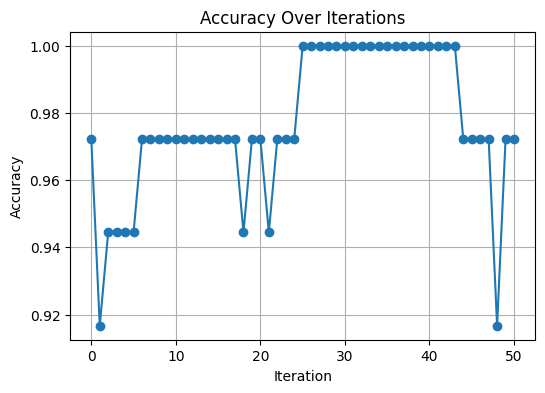

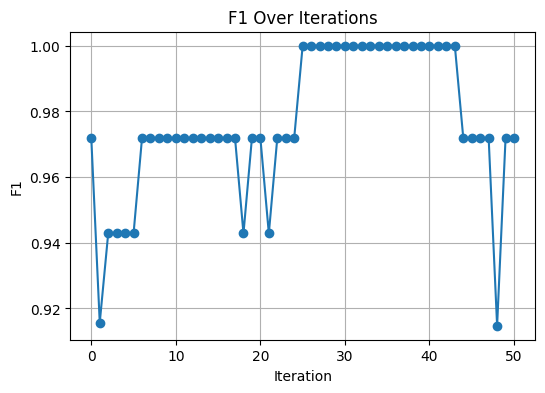

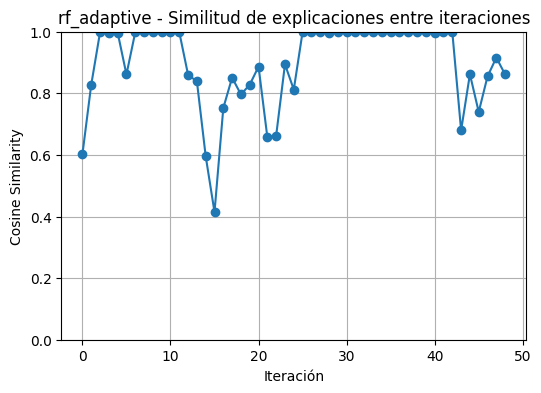

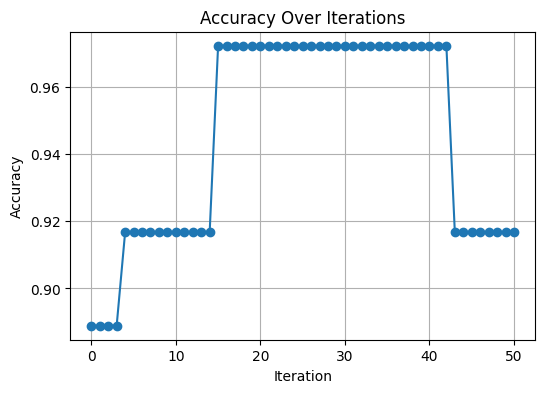

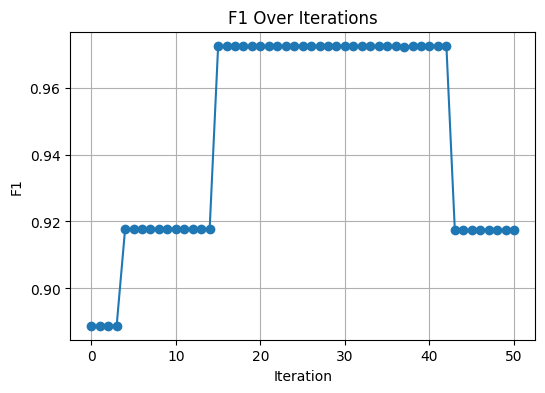

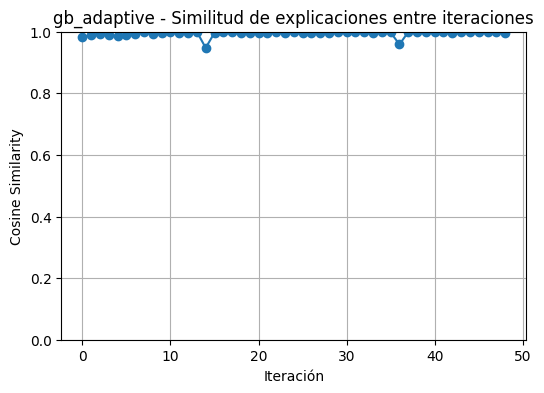

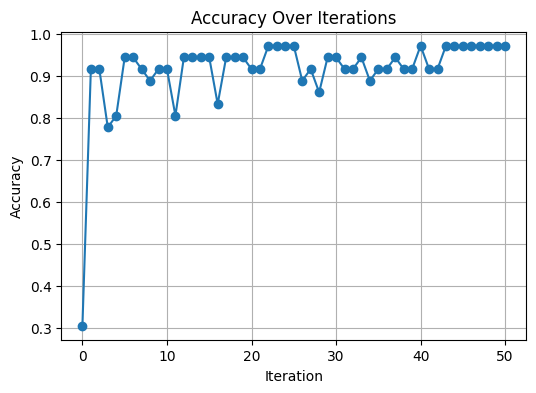

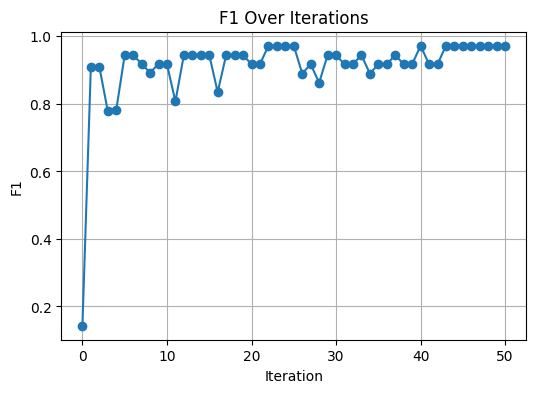

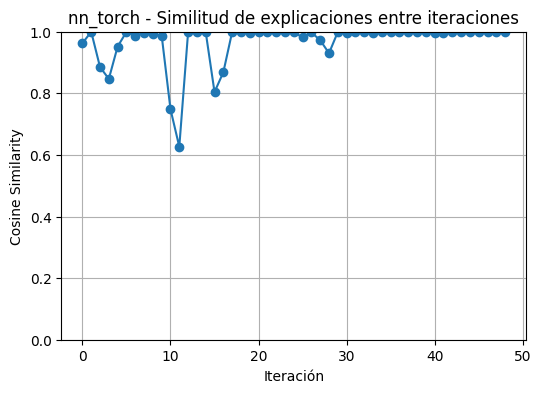


[Visualización] Divergencia global de explicaciones



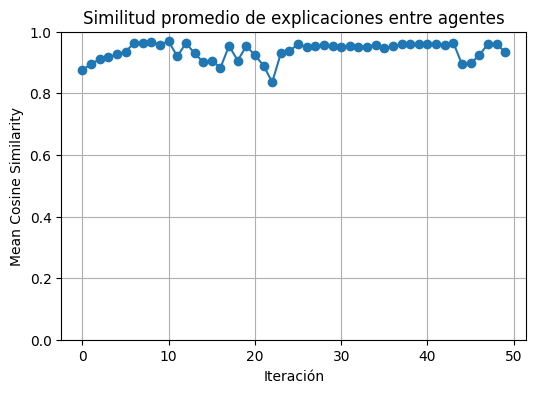


[Visualización] Dashboard global



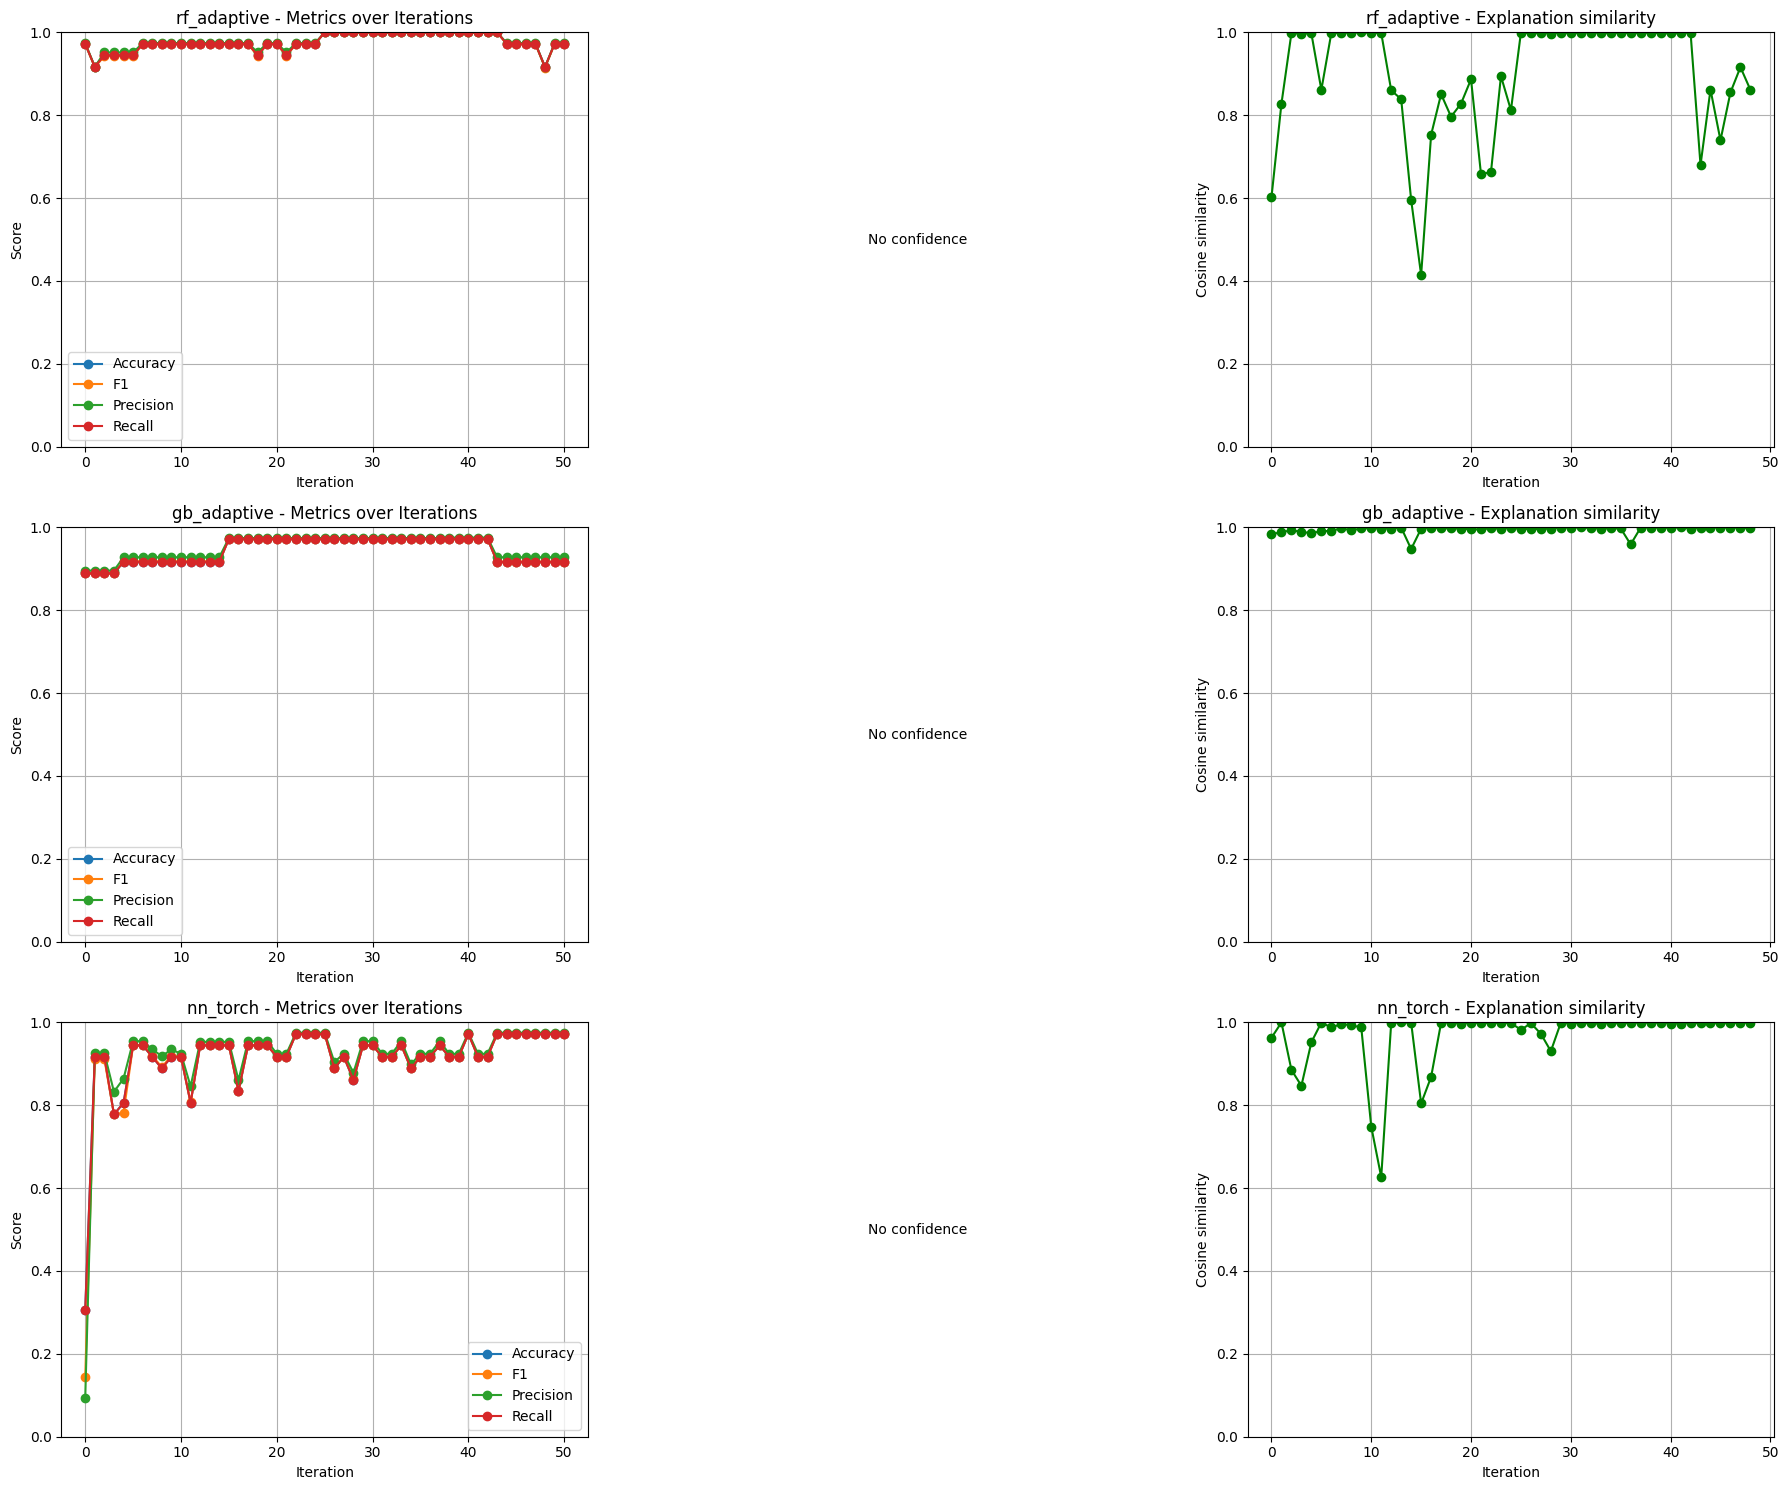


[Resumen] Medias por agente:
             accuracy     f1  exp_quality  exp_consensus  exp_stability  \
agent                                                                     
gb_adaptive     0.946  0.946        0.542          0.956          0.984   
nn_torch        0.913  0.910        0.846          0.933          0.991   
rf_adaptive     0.977  0.977        0.538          0.888          0.942   

             exp_fidelity  exp_agreement  
agent                                     
gb_adaptive         0.000           0.06  
nn_torch            0.569           0.98  
rf_adaptive         0.000           0.24  

[Resumen] Evolución media por iteración:
           accuracy     f1  exp_quality  exp_fidelity  exp_agreement
iteration                                                           
0             0.722  0.668        0.547         0.063          0.333
1             0.907  0.905        0.605         0.198          0.333
2             0.917  0.914        0.623         0.173        

,agent,iteration,accuracy,f1,precision,recall,exp_quality,exp_consensus,exp_stability,exp_fidelity,...,shap_consensus,shap_stability,shap_fidelity,lime_consensus,lime_stability,lime_fidelity,shap_top_feature,lime_top_feature,shap_lime_agree,decision
1,gb_adaptive,0,0.888889,0.888872,0.895701,0.888889,0.541593,0.971976,1.000000,0.0,...,0.991136,1.000000,0.0,0.952815,1.000000,0.0,proline,alcohol,False,keep
4,gb_adaptive,1,0.888889,0.888872,0.895701,0.888889,0.543948,0.980813,0.998815,0.0,...,0.982250,0.998174,0.0,0.979376,0.999456,0.0,proline,alcohol,False,adjust
7,gb_adaptive,2,0.888889,0.888872,0.895701,0.888889,0.543043,0.977479,0.999198,0.0,...,0.972174,0.999453,0.0,0.982785,0.998943,0.0,proline,alcohol,False,adjust
10,gb_adaptive,3,0.888889,0.888872,0.895701,0.888889,0.693800,0.980234,0.998919,0.0,...,0.983141,0.999477,0.0,0.977326,0.998361,0.0,proline,proline,True,soft_adjust
13,gb_adaptive,4,0.916667,0.917769,0.927778,0.916667,0.529898,0.960501,0.966990,0.0,...,0.972027,0.987724,0.0,0.948976,0.946256,0.0,proline,color_intensity,False,soft_adjust
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135,rf_adaptive,45,0.972222,0.971884,0.974074,0.972222,0.445817,0.745159,0.889079,0.0,...,0.722912,0.862682,0.0,0.767405,0.915477,0.0,flavanoids,color_intensity,False,soft_adjust
138,rf_adaptive,46,0.972222,0.971884,0.974074,0.972222,0.476059,0.811561,0.930362,0.0,...,0.813598,0.942279,0.0,0.809524,0.918446,0.0,proline,alcohol,False,soft_adjust
141,rf_adaptive,47,0.972222,0.971884,0.974074,0.972222,0.469713,0.784579,0.937356,0.0,...,0.819297,0.957859,0.0,0.749862,0.916853,0.0,proline,color_intensity,False,soft_adjust
144,rf_adaptive,48,0.916667,0.914730,0.915179,0.916667,0.487542,0.848429,0.932054,0.0,...,0.902893,0.956513,0.0,0.793965,0.907595,0.0,proline,alcohol,False,soft_adjust


In [4]:
import asyncio
import numpy as np
import torch
import pandas as pd

from sklearn.datasets import load_wine

from data.dataset_registry import DatasetRegistry
from data.loaders.sklearn_loader import SklearnLoader

from agents.classifier_agent import ClassifierAgent
from agents.aggregator_agent import AggregatorAgent

from explainers.shap_explainer import ShapExplainer
from explainers.lime_explainer import LimeExplainer

from models.torch_model import TorchModel
from models.random_forest import RandomForest
from models.gradient_boosting import GradientBoostingModel

from visualization.visualization import (
    plot_metrics_over_time,
    plot_explanation_similarity,
    plot_explanation_divergence,
    plot_agents_dashboard
)
from visualization.logs import log

import torch.nn as nn


class SmallMLP(nn.Module):
    def __init__(self, input_dim=13, num_classes=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 8),
            nn.ReLU(),
            nn.Linear(8, num_classes)
        )

    def forward(self, x):
        return self.net(x)


def _top_feature(explanation, feature_names):
    """Devuelve el nombre de la feature con mayor magnitud en la explicación."""
    if explanation is None:
        return None
    try:
        values = np.array(explanation["details"]["values"])
        idx = int(np.argmax(np.abs(values)))
        if feature_names and idx < len(feature_names):
            return feature_names[idx]
        return f"f{idx}"
    except Exception:
        return None


async def run_test():
    print("\n==================== TEST MULTI-AGENT (WINE + SHAP + LIME) ====================")

    # ------------------- Dataset -------------------
    registry = DatasetRegistry()
    dataset_id = "wine"
    registry.register(dataset_id, SklearnLoader(load_wine))

    X, y, meta = registry.load(dataset_id)
    feature_names = list(meta["feature_names"])
    class_names   = [str(c) for c in np.unique(y)]

    print(f"[Dataset] {dataset_id} cargado → X={X.shape}, y={y.shape}")
    print(f"[Dataset] Features: {feature_names}")

    instance = X[:1]

    # -------------------------------------------------------
    # Explainers — instancias independientes por agente
    # -------------------------------------------------------
    def make_explainers():
        return [
            ShapExplainer(feature_names=feature_names),
            LimeExplainer(
                feature_names=feature_names,
                class_names=class_names,
                discretize_continuous=False
            )
        ]

    # -------------------------------------------------------
    # Modelos
    # -------------------------------------------------------
    rf_model = RandomForest(
        n_estimators=10,
        max_depth=2,
        random_state=0
    )

    gb_model = GradientBoostingModel(
        n_estimators=3,
        learning_rate=0.9,
        max_depth=1
    )

    torch_model = TorchModel(
        nn_model=SmallMLP(input_dim=X.shape[1], num_classes=len(np.unique(y))),
        lr=0.02,
        min_lr=1e-4,
        max_lr=0.15,
        epochs=5,
        batch_size=16
    )

    # ------------------- Clasificadores -------------------
    classifiers = {
        "rf_adaptive": ClassifierAgent(
            agent_id="rf_adaptive",
            model=rf_model,
            explainers=make_explainers(),
            dataset_id=dataset_id,
            registry=registry
        ),
        "gb_adaptive": ClassifierAgent(
            agent_id="gb_adaptive",
            model=gb_model,
            explainers=make_explainers(),
            dataset_id=dataset_id,
            registry=registry
        ),
        "nn_torch": ClassifierAgent(
            agent_id="nn_torch",
            model=torch_model,
            explainers=make_explainers(),
            dataset_id=dataset_id,
            registry=registry
        )
    }

    classifier_ids = list(classifiers.keys())

    aggregator = AggregatorAgent(
        classifier_ids=classifier_ids,
        alpha=0.4,
        beta=0.15,
        gamma=0.25
    )

    queues = {cid: agent.inbox for cid, agent in classifiers.items()}
    queues["aggregator"] = aggregator.inbox

    # ------------------- Setup -------------------
    print("\n[Setup] Inicializando agentes...\n")
    await asyncio.gather(*(agent.setup() for agent in classifiers.values()))
    log("Inicializando AggregatorAgent")

    # ------------------- Tasks -------------------
    tasks = [
        asyncio.create_task(agent.run(queues))
        for agent in classifiers.values()
    ]
    tasks.append(
        asyncio.create_task(aggregator.run(queues, instance))
    )

    await asyncio.gather(*tasks, return_exceptions=True)

    for entry in aggregator.global_history:
        print(f"\n--- Iter {entry['iteration']} ---")
        ed = entry['evaluation']['components']['exp_detail']
        print(f"consensus:  {[round(x,3) for x in ed['consensus']]}")
        print(f"stability:  {[round(x,3) for x in ed['stability']]}")
        print(f"fidelity:   {[round(x,3) for x in ed['fidelity']]}")
        print(f"agreement:  {[round(x,3) for x in ed['agreement']]}")
        print(f"quality:    {[round(x,3) for x in ed['quality']]}")
        print(f"scores:     {[round(x,3) for x in entry['evaluation']['scores']]}")
        print(f"conf:       {[round(x,3) for x in entry['evaluation']['components']['conf']]}")
        print(f"decisions:  {entry['decisions']}")
        print("\n==================== TEST FINALIZADO ✅ ====================\n")

    # =========================================================
    # VISUALIZACIÓN
    # =========================================================
    print("\n[Visualización] Métricas por agente\n")
    for agent in classifiers.values():
        plot_metrics_over_time(agent.metrics_history, metric_name="accuracy")
        plot_metrics_over_time(agent.metrics_history, metric_name="f1")
        plot_explanation_similarity(agent)

    print("\n[Visualización] Divergencia global de explicaciones\n")
    plot_explanation_divergence(classifiers)

    print("\n[Visualización] Dashboard global\n")
    plot_agents_dashboard(classifiers)

    # =========================================================
    # DataFrame de resultados
    # =========================================================
    rows = []

    for entry in aggregator.global_history:
        iteration     = entry["iteration"]
        evaluation    = entry["evaluation"]
        exp_detail    = evaluation["components"]["exp_detail"]
        per_explainer = exp_detail.get("per_explainer", {})
        decisions     = entry["decisions"]

        for idx, agent_id in enumerate(classifier_ids):
            explanations = entry["responses"][idx].get("explanations", [])

            # Explicación individual de cada método
            shap_exp = next((e for e in explanations if e.get("explainer") == "shap"), None)
            lime_exp = next((e for e in explanations if e.get("explainer") == "lime"), None)

            # Feature más importante por método
            shap_top = _top_feature(shap_exp, feature_names)
            lime_top = _top_feature(lime_exp, feature_names)

            # Métricas por explainer con fallback seguro
            def _get(name, metric):
                arr = per_explainer.get(name, {}).get(metric, [])
                return arr[idx] if idx < len(arr) else None

            row = {
                "agent":          agent_id,
                "iteration":      iteration,
                "accuracy":       entry["responses"][idx]["metrics"]["accuracy"],
                "f1":             entry["responses"][idx]["metrics"]["f1"],
                "precision":      entry["responses"][idx]["metrics"]["precision"],
                "recall":         entry["responses"][idx]["metrics"]["recall"],
                # Métricas globales (promedio entre explainers)
                "exp_quality":    exp_detail["quality"][idx],
                "exp_consensus":  exp_detail["consensus"][idx],
                "exp_stability":  exp_detail["stability"][idx],
                "exp_fidelity":   exp_detail["fidelity"][idx],
                "exp_agreement":  exp_detail["agreement"][idx],
                # Por explainer
                "shap_consensus": _get("shap", "consensus"),
                "shap_stability": _get("shap", "stability"),
                "shap_fidelity":  _get("shap", "fidelity"),
                "lime_consensus": _get("lime", "consensus"),
                "lime_stability": _get("lime", "stability"),
                "lime_fidelity":  _get("lime", "fidelity"),
                # Top feature
                "shap_top_feature": shap_top,
                "lime_top_feature": lime_top,
                "shap_lime_agree":  shap_top == lime_top and shap_top is not None,
                "decision":       decisions[idx],
            }
            rows.append(row)

    df = pd.DataFrame(rows)
    df_sorted = df.sort_values(["agent", "iteration"])

    # ---- Resúmenes ----
    print("\n[Resumen] Medias por agente:")
    print(df_sorted.groupby("agent")[[
        "accuracy", "f1", "exp_quality", "exp_consensus",
        "exp_stability", "exp_fidelity", "exp_agreement"
    ]].mean().round(3))

    print("\n[Resumen] Evolución media por iteración:")
    print(df_sorted.groupby("iteration")[[
        "accuracy", "f1", "exp_quality", "exp_fidelity", "exp_agreement"
    ]].mean().round(3))

    print("\n[Resumen] Distribución de decisiones por agente:")
    print(df_sorted.groupby(["agent", "decision"]).size().unstack(fill_value=0))

    print("\n[Resumen] Acuerdo SHAP vs LIME por agente (% iteraciones):")
    print(df_sorted.groupby("agent")["shap_lime_agree"].mean().round(3))

    print("\n[Resumen] Fidelity SHAP vs LIME por agente:")
    print(df_sorted.groupby("agent")[["shap_fidelity", "lime_fidelity"]].mean().round(3))

    print("\n[Resumen] Consensus SHAP vs LIME por agente:")
    print(df_sorted.groupby("agent")[["shap_consensus", "lime_consensus"]].mean().round(3))

    print("\n[Resumen] Feature más votada por SHAP y LIME:")
    for agent_id in classifier_ids:
        sub = df_sorted[df_sorted["agent"] == agent_id]
        print(f"\n  {agent_id}:")
        print(f"    SHAP top: {sub['shap_top_feature'].value_counts().head(3).to_dict()}")
        print(f"    LIME top: {sub['lime_top_feature'].value_counts().head(3).to_dict()}")

    return df_sorted


await run_test()